# Steam Dataset EDA for Recommendation Models
## Analysis for EASE, BPR, LightGCN, and NeuMF Models

This notebook performs comprehensive exploratory data analysis on the Steam interaction dataset to understand data characteristics crucial for:
- **EASE**: Linear model requiring interaction matrix sparsity analysis
- **BPR**: Pairwise ranking model needing popularity and user activity distributions
- **LightGCN**: Graph-based model requiring connectivity and degree analysis
- **NeuMF**: Neural collaborative filtering needing embedding space insights

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Data Loading and Basic Information

In [2]:
# Load the dataset
data_path = '../dataset/steam/steam.inter'

# Read the data
df = pd.read_csv(data_path, delimiter=',')

print("Data loaded successfully!")
print(f"Dataset shape: {df.shape}")
print(f"\nColumn names: {df.columns.tolist()}")

Data loaded successfully!
Dataset shape: (31513724, 3)

Column names: ['user_id:token', 'item_id:token', 'rating:float']


In [3]:
# Display first few rows
print("First 10 rows of the dataset:")
df.head(10)

First 10 rows of the dataset:


,user_id:token,item_id:token,rating:float
0,76561198030711809,50,1
1,76561198030711809,70,1
2,76561198030711809,130,1
3,76561198030711809,220,1
4,76561198030711809,550,1
5,76561198030711809,570,1
6,76561198030711809,620,1
7,76561198030711809,2100,1
8,76561198030711809,2600,1
9,76561198030711809,2870,1


In [4]:
# Basic statistics
print("=" * 60)
print("BASIC DATASET STATISTICS")
print("=" * 60)
print(f"Total interactions: {len(df):,}")
print(f"Unique users: {df['user_id:token'].nunique():,}")
print(f"Unique items: {df['item_id:token'].nunique():,}")
print(f"\nRating statistics:")
print(df['rating:float'].describe())
print(f"\nRating value counts:")
print(df['rating:float'].value_counts())

BASIC DATASET STATISTICS
Total interactions: 31,513,724
Unique users: 222,151
Unique items: 50,367

Rating statistics:
count    31513724.0
mean            1.0
std             0.0
min             1.0
25%             1.0
50%             1.0
75%             1.0
max             1.0
Name: rating:float, dtype: float64

Rating value counts:
rating:float
1    31513724
Name: count, dtype: int64


In [5]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")

Missing values:
user_id:token    0
item_id:token    0
rating:float     0
dtype: int64

Duplicate rows: 0


## 2. Sparsity Analysis (Critical for EASE & All Models)

In [6]:
# Calculate sparsity
n_users = df['user_id:token'].nunique()
n_items = df['item_id:token'].nunique()
n_interactions = len(df)

sparsity = 1 - (n_interactions / (n_users * n_items))
density = n_interactions / (n_users * n_items)

print("=" * 60)
print("SPARSITY ANALYSIS")
print("=" * 60)
print(f"Total possible interactions: {n_users * n_items:,}")
print(f"Actual interactions: {n_interactions:,}")
print(f"Sparsity: {sparsity:.6f} ({sparsity * 100:.4f}%)")
print(f"Density: {density:.6f} ({density * 100:.4f}%)")
print(f"\nAverage interactions per user: {n_interactions / n_users:.2f}")
print(f"Average interactions per item: {n_interactions / n_items:.2f}")

SPARSITY ANALYSIS
Total possible interactions: 11,189,079,417
Actual interactions: 31,513,724
Sparsity: 0.997184 (99.7184%)
Density: 0.002816 (0.2816%)

Average interactions per user: 141.86
Average interactions per item: 625.68


## 3. User Activity Analysis (Critical for BPR & NeuMF)

In [7]:
# User interaction counts
user_interaction_counts = df.groupby('user_id:token').size()

print("=" * 60)
print("USER ACTIVITY STATISTICS")
print("=" * 60)
print(user_interaction_counts.describe())
print(f"\nMedian interactions per user: {user_interaction_counts.median():.2f}")
print(f"Mode interactions per user: {user_interaction_counts.mode()[0]}")

# Percentiles
percentiles = [10, 25, 50, 75, 90, 95, 99]
print("\nUser interaction percentiles:")
for p in percentiles:
    val = np.percentile(user_interaction_counts, p)
    print(f"  {p}th percentile: {val:.2f}")

USER ACTIVITY STATISTICS
count    222151.000000
mean        141.857223
std         391.595459
min           1.000000
25%          25.000000
50%          65.000000
75%         145.000000
max       32811.000000
dtype: float64

Median interactions per user: 65.00
Mode interactions per user: 3

User interaction percentiles:
  10th percentile: 9.00
  25th percentile: 25.00
  50th percentile: 65.00
  75th percentile: 145.00
  90th percentile: 279.00
  95th percentile: 424.00
  99th percentile: 1306.00


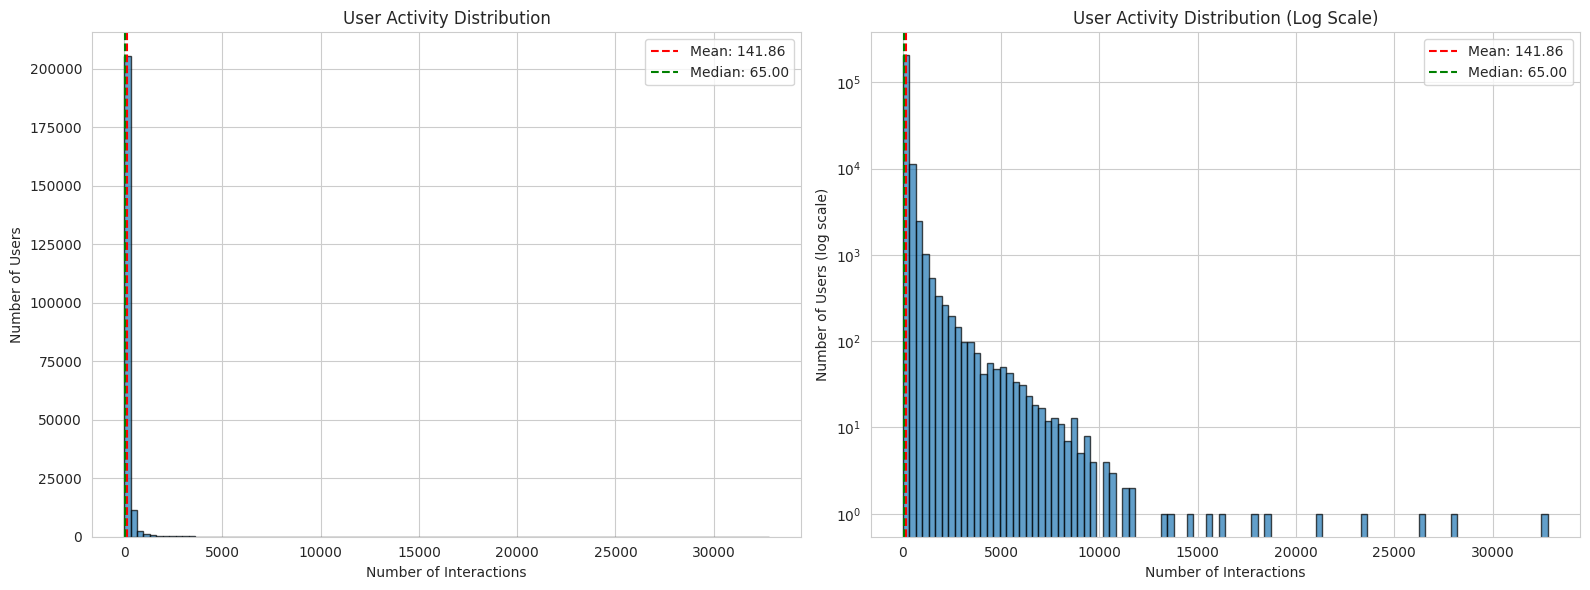

In [8]:
# Visualize user activity distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
axes[0].hist(user_interaction_counts, bins=100, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Number of Interactions')
axes[0].set_ylabel('Number of Users')
axes[0].set_title('User Activity Distribution')
axes[0].axvline(user_interaction_counts.mean(), color='red', linestyle='--', label=f'Mean: {user_interaction_counts.mean():.2f}')
axes[0].axvline(user_interaction_counts.median(), color='green', linestyle='--', label=f'Median: {user_interaction_counts.median():.2f}')
axes[0].legend()

# Log scale histogram
axes[1].hist(user_interaction_counts, bins=100, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Number of Interactions')
axes[1].set_ylabel('Number of Users (log scale)')
axes[1].set_title('User Activity Distribution (Log Scale)')
axes[1].set_yscale('log')
axes[1].axvline(user_interaction_counts.mean(), color='red', linestyle='--', label=f'Mean: {user_interaction_counts.mean():.2f}')
axes[1].axvline(user_interaction_counts.median(), color='green', linestyle='--', label=f'Median: {user_interaction_counts.median():.2f}')
axes[1].legend()

plt.tight_layout()
plt.show()

In [9]:
# User activity segmentation
def categorize_user(count):
    if count < 10:
        return 'Inactive (1-9)'
    elif count < 50:
        return 'Low Activity (10-49)'
    elif count < 100:
        return 'Medium Activity (50-99)'
    elif count < 500:
        return 'High Activity (100-499)'
    else:
        return 'Very High Activity (500+)'

user_segments = user_interaction_counts.apply(categorize_user).value_counts()
print("\nUser Segmentation:")
for segment, count in user_segments.items():
    percentage = (count / n_users) * 100
    print(f"  {segment}: {count:,} users ({percentage:.2f}%)")


User Segmentation:
  High Activity (100-499): 72,711 users (32.73%)
  Low Activity (10-49): 69,035 users (31.08%)
  Medium Activity (50-99): 48,459 users (21.81%)
  Inactive (1-9): 23,363 users (10.52%)
  Very High Activity (500+): 8,583 users (3.86%)


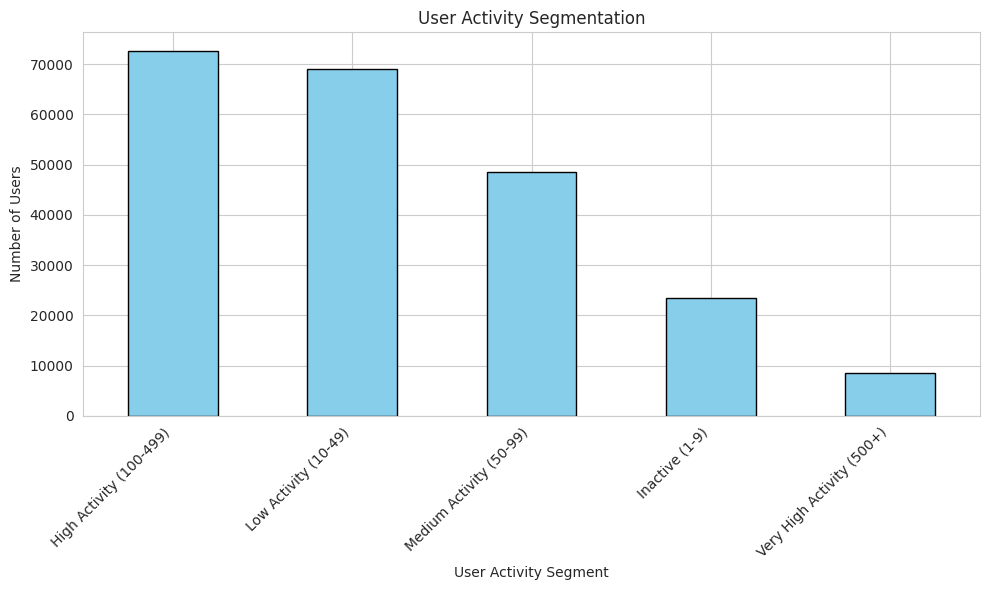

In [10]:
# Visualize user segmentation
plt.figure(figsize=(10, 6))
user_segments.plot(kind='bar', color='skyblue', edgecolor='black')
plt.xlabel('User Activity Segment')
plt.ylabel('Number of Users')
plt.title('User Activity Segmentation')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 4. Item Popularity Analysis (Critical for BPR & All Models)

In [11]:
# Item interaction counts
item_interaction_counts = df.groupby('item_id:token').size()

print("=" * 60)
print("ITEM POPULARITY STATISTICS")
print("=" * 60)
print(item_interaction_counts.describe())
print(f"\nMedian interactions per item: {item_interaction_counts.median():.2f}")
print(f"Mode interactions per item: {item_interaction_counts.mode()[0]}")

# Percentiles
print("\nItem interaction percentiles:")
for p in percentiles:
    val = np.percentile(item_interaction_counts, p)
    print(f"  {p}th percentile: {val:.2f}")

ITEM POPULARITY STATISTICS
count     50367.000000
mean        625.681974
std        3058.994166
min           1.000000
25%           9.000000
50%          39.000000
75%         284.000000
max      200905.000000
dtype: float64

Median interactions per item: 39.00
Mode interactions per item: 1

Item interaction percentiles:
  10th percentile: 3.00
  25th percentile: 9.00
  50th percentile: 39.00
  75th percentile: 284.00
  90th percentile: 1236.00
  95th percentile: 2471.70
  99th percentile: 9945.12


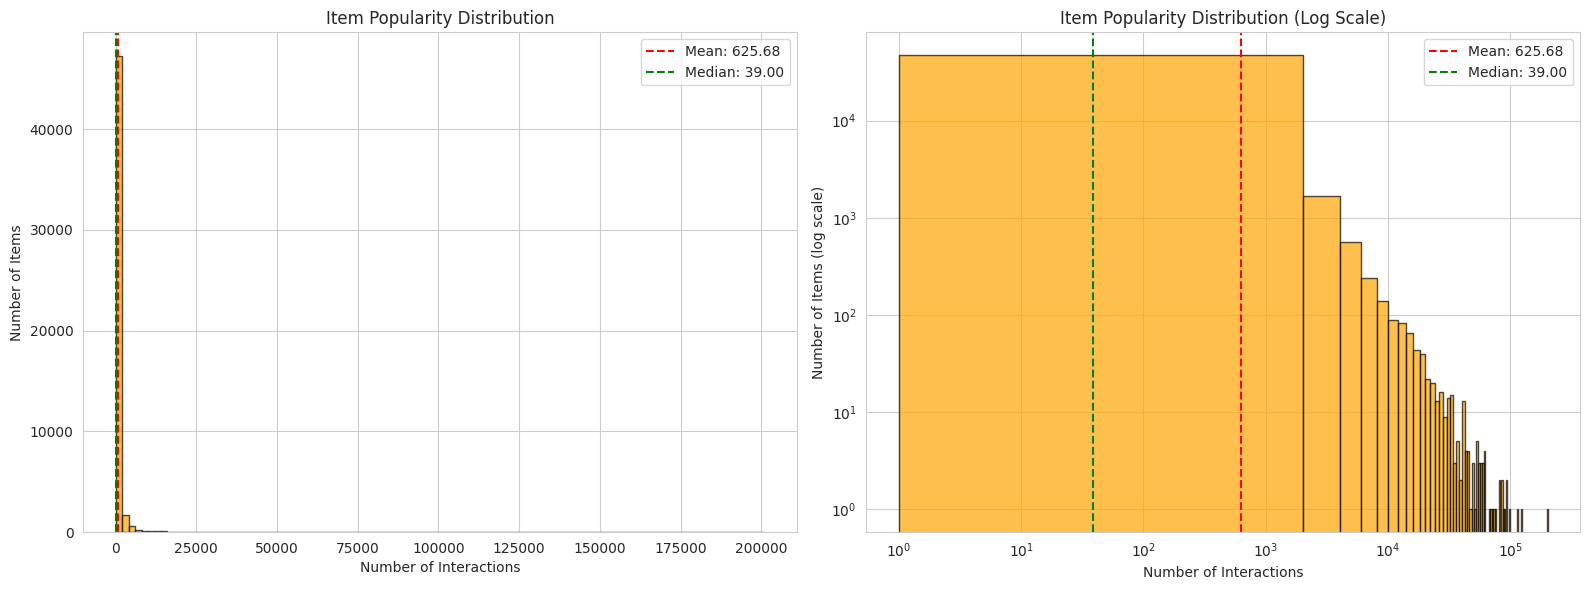

In [12]:
# Visualize item popularity distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
axes[0].hist(item_interaction_counts, bins=100, edgecolor='black', alpha=0.7, color='orange')
axes[0].set_xlabel('Number of Interactions')
axes[0].set_ylabel('Number of Items')
axes[0].set_title('Item Popularity Distribution')
axes[0].axvline(item_interaction_counts.mean(), color='red', linestyle='--', label=f'Mean: {item_interaction_counts.mean():.2f}')
axes[0].axvline(item_interaction_counts.median(), color='green', linestyle='--', label=f'Median: {item_interaction_counts.median():.2f}')
axes[0].legend()

# Log scale histogram
axes[1].hist(item_interaction_counts, bins=100, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_xlabel('Number of Interactions')
axes[1].set_ylabel('Number of Items (log scale)')
axes[1].set_title('Item Popularity Distribution (Log Scale)')
axes[1].set_yscale('log')
axes[1].set_xscale('log')
axes[1].axvline(item_interaction_counts.mean(), color='red', linestyle='--', label=f'Mean: {item_interaction_counts.mean():.2f}')
axes[1].axvline(item_interaction_counts.median(), color='green', linestyle='--', label=f'Median: {item_interaction_counts.median():.2f}')
axes[1].legend()

plt.tight_layout()
plt.show()

In [13]:
# Item popularity segmentation
def categorize_item(count):
    if count < 10:
        return 'Very Rare (1-9)'
    elif count < 50:
        return 'Rare (10-49)'
    elif count < 100:
        return 'Uncommon (50-99)'
    elif count < 500:
        return 'Common (100-499)'
    elif count < 1000:
        return 'Popular (500-999)'
    else:
        return 'Very Popular (1000+)'

item_segments = item_interaction_counts.apply(categorize_item).value_counts()
print("\nItem Popularity Segmentation:")
for segment, count in item_segments.items():
    percentage = (count / n_items) * 100
    print(f"  {segment}: {count:,} items ({percentage:.2f}%)")


Item Popularity Segmentation:
  Rare (10-49): 14,429 items (28.65%)
  Very Rare (1-9): 12,608 items (25.03%)
  Common (100-499): 8,915 items (17.70%)
  Very Popular (1000+): 6,013 items (11.94%)
  Uncommon (50-99): 4,882 items (9.69%)
  Popular (500-999): 3,520 items (6.99%)


In [14]:
# Top 20 most popular items
top_20_items = item_interaction_counts.nlargest(20)
print("\nTop 20 Most Popular Items:")
for idx, (item_id, count) in enumerate(top_20_items.items(), 1):
    percentage = (count / n_interactions) * 100
    print(f"  {idx}. Item {item_id}: {count:,} interactions ({percentage:.2f}% of total)")


Top 20 Most Popular Items:
  1. Item 730: 200,905 interactions (0.64% of total)
  2. Item 578080: 123,643 interactions (0.39% of total)
  3. Item 550: 114,514 interactions (0.36% of total)
  4. Item 218620: 98,061 interactions (0.31% of total)
  5. Item 431960: 93,913 interactions (0.30% of total)
  6. Item 4000: 92,652 interactions (0.29% of total)
  7. Item 304930: 89,362 interactions (0.28% of total)
  8. Item 271590: 88,050 interactions (0.28% of total)
  9. Item 1172470: 86,343 interactions (0.27% of total)
  10. Item 945360: 84,982 interactions (0.27% of total)
  11. Item 359550: 81,830 interactions (0.26% of total)
  12. Item 105600: 81,576 interactions (0.26% of total)
  13. Item 620: 74,662 interactions (0.24% of total)
  14. Item 230410: 73,408 interactions (0.23% of total)
  15. Item 242760: 71,316 interactions (0.23% of total)
  16. Item 252490: 69,321 interactions (0.22% of total)
  17. Item 291550: 67,745 interactions (0.21% of total)
  18. Item 444090: 61,621 interactio

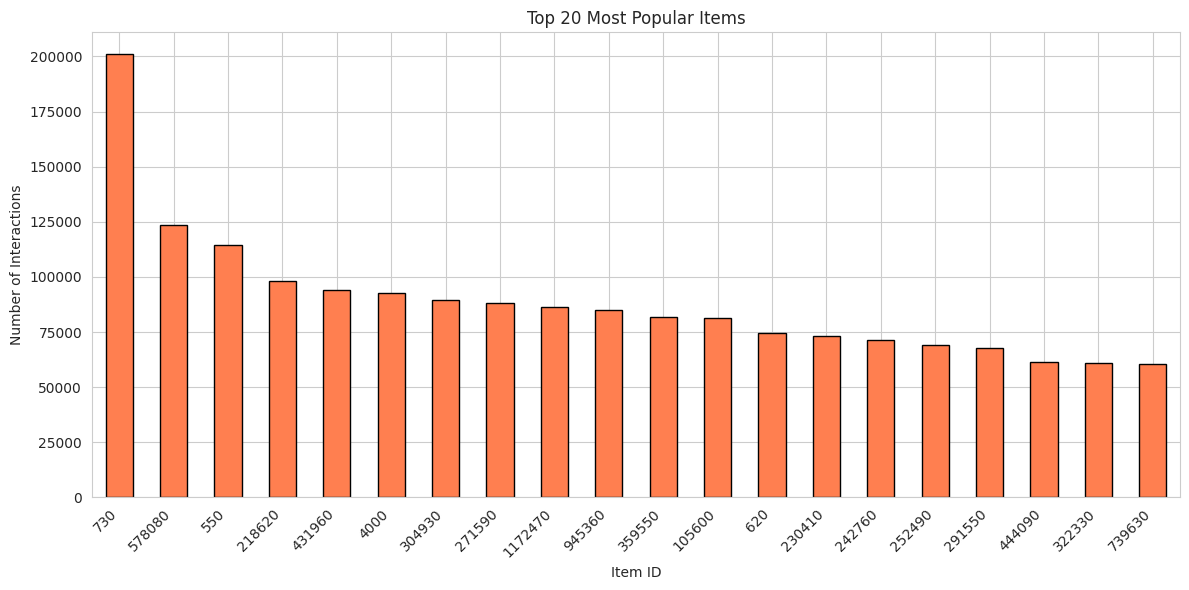

In [15]:
# Visualize top 20 items
plt.figure(figsize=(12, 6))
top_20_items.plot(kind='bar', color='coral', edgecolor='black')
plt.xlabel('Item ID')
plt.ylabel('Number of Interactions')
plt.title('Top 20 Most Popular Items')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 5. Long-tail Analysis (Critical for All Models)

In [16]:
# Calculate cumulative distribution
item_counts_sorted = item_interaction_counts.sort_values(ascending=False)
cumulative_interactions = item_counts_sorted.cumsum()
cumulative_percentage = (cumulative_interactions / n_interactions) * 100

# Find how many items account for 80% of interactions (80/20 rule)
items_for_80_percent = (cumulative_percentage <= 80).sum()
percentage_items_for_80 = (items_for_80_percent / n_items) * 100

print("=" * 60)
print("LONG-TAIL ANALYSIS")
print("=" * 60)
print(f"Top {items_for_80_percent:,} items ({percentage_items_for_80:.2f}%) account for 80% of interactions")
print(f"Remaining {n_items - items_for_80_percent:,} items ({100 - percentage_items_for_80:.2f}%) account for 20% of interactions")

LONG-TAIL ANALYSIS
Top 5,234 items (10.39%) account for 80% of interactions
Remaining 45,133 items (89.61%) account for 20% of interactions


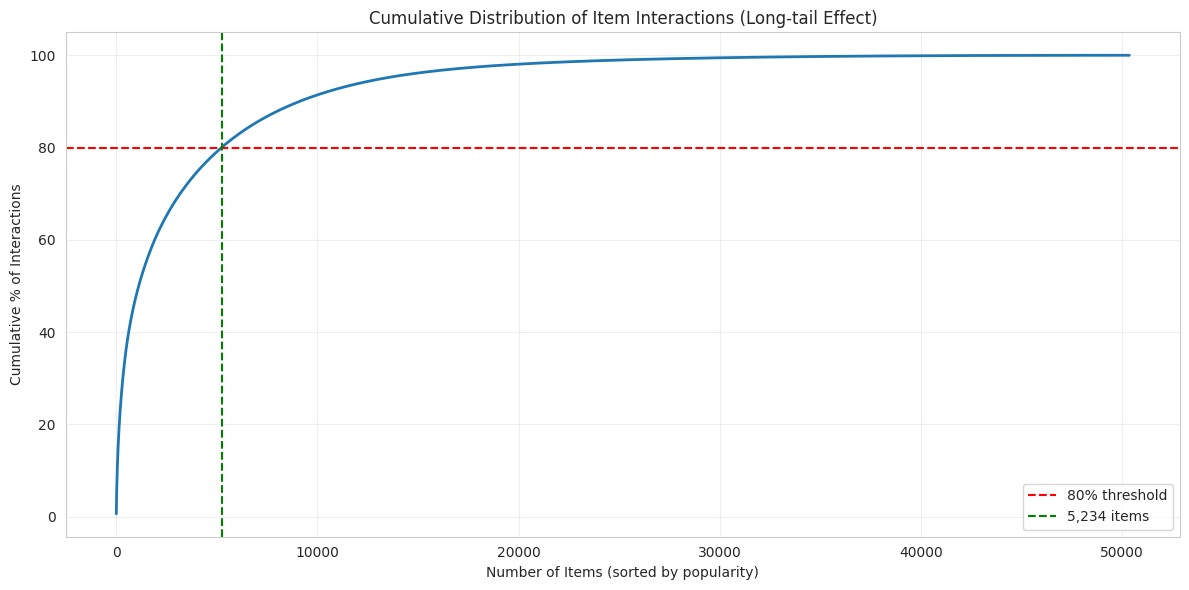

In [17]:
# Visualize cumulative distribution
plt.figure(figsize=(12, 6))
plt.plot(range(len(cumulative_percentage)), cumulative_percentage.values, linewidth=2)
plt.axhline(y=80, color='red', linestyle='--', label='80% threshold')
plt.axvline(x=items_for_80_percent, color='green', linestyle='--', label=f'{items_for_80_percent:,} items')
plt.xlabel('Number of Items (sorted by popularity)')
plt.ylabel('Cumulative % of Interactions')
plt.title('Cumulative Distribution of Item Interactions (Long-tail Effect)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Graph Structure Analysis (Critical for LightGCN)

In [18]:
# Calculate degree statistics for bipartite graph
print("=" * 60)
print("GRAPH STRUCTURE ANALYSIS (User-Item Bipartite Graph)")
print("=" * 60)

# User degree (number of items per user)
user_degrees = user_interaction_counts
print("\nUser Degree Statistics:")
print(f"  Mean degree: {user_degrees.mean():.2f}")
print(f"  Median degree: {user_degrees.median():.2f}")
print(f"  Min degree: {user_degrees.min()}")
print(f"  Max degree: {user_degrees.max()}")
print(f"  Std deviation: {user_degrees.std():.2f}")

# Item degree (number of users per item)
item_degrees = item_interaction_counts
print("\nItem Degree Statistics:")
print(f"  Mean degree: {item_degrees.mean():.2f}")
print(f"  Median degree: {item_degrees.median():.2f}")
print(f"  Min degree: {item_degrees.min()}")
print(f"  Max degree: {item_degrees.max()}")
print(f"  Std deviation: {item_degrees.std():.2f}")

# Graph density
print(f"\nGraph density: {density:.6f}")
print(f"Total edges (interactions): {n_interactions:,}")
print(f"Total nodes (users + items): {n_users + n_items:,}")

GRAPH STRUCTURE ANALYSIS (User-Item Bipartite Graph)

User Degree Statistics:
  Mean degree: 141.86
  Median degree: 65.00
  Min degree: 1
  Max degree: 32811
  Std deviation: 391.60

Item Degree Statistics:
  Mean degree: 625.68
  Median degree: 39.00
  Min degree: 1
  Max degree: 200905
  Std deviation: 3058.99

Graph density: 0.002816
Total edges (interactions): 31,513,724
Total nodes (users + items): 272,518


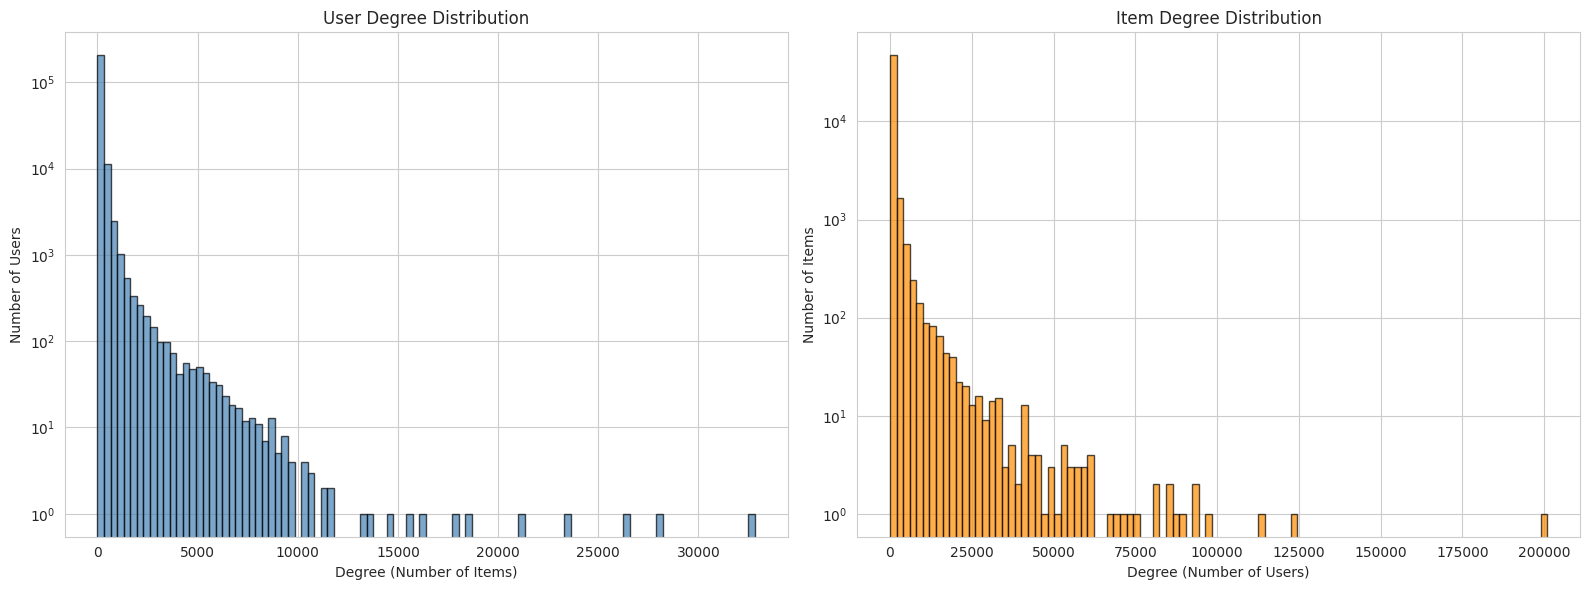

In [19]:
# Degree distribution comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# User degrees
axes[0].hist(user_degrees, bins=100, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('Degree (Number of Items)')
axes[0].set_ylabel('Number of Users')
axes[0].set_title('User Degree Distribution')
axes[0].set_yscale('log')

# Item degrees
axes[1].hist(item_degrees, bins=100, edgecolor='black', alpha=0.7, color='darkorange')
axes[1].set_xlabel('Degree (Number of Users)')
axes[1].set_ylabel('Number of Items')
axes[1].set_title('Item Degree Distribution')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

## 7. Rating Distribution Analysis

In [20]:
# Rating distribution
rating_counts = df['rating:float'].value_counts().sort_index()

print("=" * 60)
print("RATING DISTRIBUTION")
print("=" * 60)
for rating, count in rating_counts.items():
    percentage = (count / n_interactions) * 100
    print(f"Rating {rating}: {count:,} ({percentage:.2f}%)")

RATING DISTRIBUTION
Rating 1: 31,513,724 (100.00%)


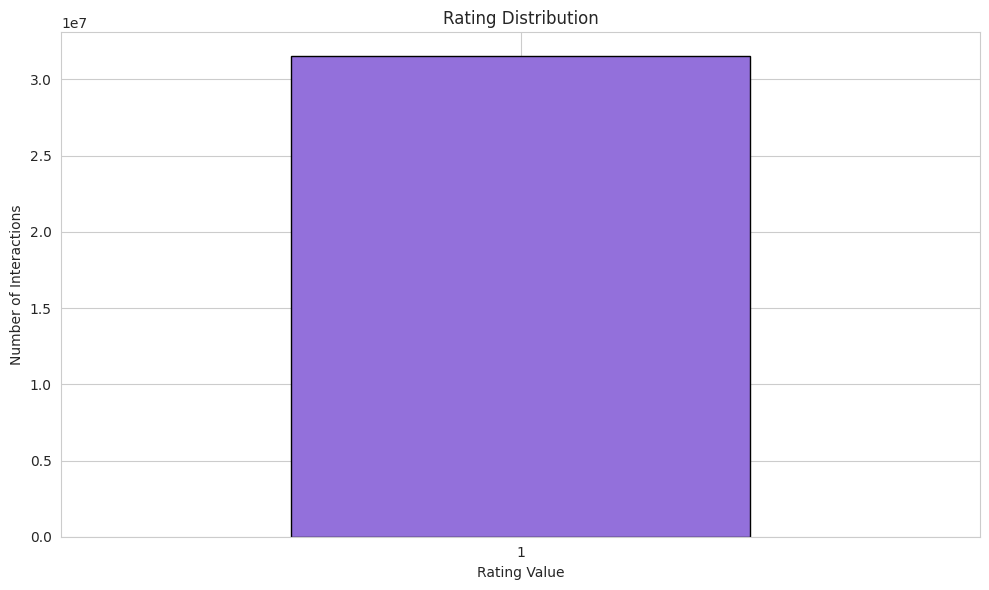

In [21]:
# Visualize rating distribution
plt.figure(figsize=(10, 6))
rating_counts.plot(kind='bar', color='mediumpurple', edgecolor='black')
plt.xlabel('Rating Value')
plt.ylabel('Number of Interactions')
plt.title('Rating Distribution')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 8. Cold Start Problem Analysis

In [22]:
# Identify cold start users and items
cold_start_threshold_user = 5
cold_start_threshold_item = 5

cold_start_users = (user_interaction_counts <= cold_start_threshold_user).sum()
cold_start_items = (item_interaction_counts <= cold_start_threshold_item).sum()

print("=" * 60)
print(f"COLD START ANALYSIS (threshold <= {cold_start_threshold_user} interactions)")
print("=" * 60)
print(f"\nCold start users: {cold_start_users:,} ({(cold_start_users/n_users)*100:.2f}%)")
print(f"Cold start items: {cold_start_items:,} ({(cold_start_items/n_items)*100:.2f}%)")

# Users with only 1 interaction
single_interaction_users = (user_interaction_counts == 1).sum()
single_interaction_items = (item_interaction_counts == 1).sum()

print(f"\nUsers with only 1 interaction: {single_interaction_users:,} ({(single_interaction_users/n_users)*100:.2f}%)")
print(f"Items with only 1 interaction: {single_interaction_items:,} ({(single_interaction_items/n_items)*100:.2f}%)")

COLD START ANALYSIS (threshold <= 5 interactions)

Cold start users: 12,585 (5.67%)
Cold start items: 8,808 (17.49%)

Users with only 1 interaction: 683 (0.31%)
Items with only 1 interaction: 2,524 (5.01%)


## 9. Interaction Matrix Characteristics (Critical for EASE)

In [23]:
# Sample-based correlation analysis (due to large dataset size)
print("=" * 60)
print("INTERACTION MATRIX CHARACTERISTICS")
print("=" * 60)

# Matrix dimensions
print(f"\nMatrix dimensions: {n_users:,} users × {n_items:,} items")
print(f"Matrix size: {n_users * n_items:,} elements")
print(f"Non-zero elements: {n_interactions:,}")
print(f"Zero elements: {(n_users * n_items) - n_interactions:,}")

# Memory estimation
bytes_per_float = 4
dense_matrix_mb = (n_users * n_items * bytes_per_float) / (1024 ** 2)
sparse_matrix_mb = (n_interactions * bytes_per_float * 3) / (1024 ** 2)  # approximate

print(f"\nMemory estimation:")
print(f"  Dense matrix: {dense_matrix_mb:,.2f} MB ({dense_matrix_mb/1024:.2f} GB)")
print(f"  Sparse matrix (approx): {sparse_matrix_mb:,.2f} MB ({sparse_matrix_mb/1024:.2f} GB)")
print(f"  Space savings: {((dense_matrix_mb - sparse_matrix_mb) / dense_matrix_mb) * 100:.2f}%")

INTERACTION MATRIX CHARACTERISTICS

Matrix dimensions: 222,151 users × 50,367 items
Matrix size: 11,189,079,417 elements
Non-zero elements: 31,513,724
Zero elements: 11,157,565,693

Memory estimation:
  Dense matrix: 42,682.95 MB (41.68 GB)
  Sparse matrix (approx): 360.65 MB (0.35 GB)
  Space savings: 99.16%


## 10. Temporal Patterns (if applicable)

In [24]:
# Check if there's any temporal information in the data
print("Dataset columns:")
print(df.columns.tolist())
print("\nNote: This dataset does not contain timestamp information.")
print("Temporal analysis is not applicable.")

Dataset columns:
['user_id:token', 'item_id:token', 'rating:float']

Note: This dataset does not contain timestamp information.
Temporal analysis is not applicable.


## 11. Model-Specific Insights Summary

In [25]:
print("=" * 80)
print("MODEL-SPECIFIC RECOMMENDATIONS")
print("=" * 80)

print("\n📊 EASE (Embarrassingly Shallow Autoencoders):")
print("  ✓ High sparsity detected - EASE is designed for sparse data")
print(f"  ✓ Sparsity level: {sparsity*100:.4f}% - suitable for linear models")
print(f"  ⚠ Matrix size: {n_users:,} × {n_items:,} - consider dimensionality reduction if memory is limited")
print("  💡 Recommendation: Use sparse matrix implementation to handle large-scale data")

print("\n🎯 BPR (Bayesian Personalized Ranking):")
print(f"  ✓ Implicit feedback data (binary ratings) - perfect for BPR")
print(f"  ✓ User activity variance: mean={user_degrees.mean():.1f}, std={user_degrees.std():.1f}")
print(f"  ✓ Long-tail distribution detected - BPR handles popularity bias well")
print("  💡 Recommendation: Use negative sampling strategy; consider popularity-based sampling")

print("\n🕸️  LightGCN (Light Graph Convolutional Network):")
print(f"  ✓ Bipartite graph structure: {n_users:,} users + {n_items:,} items = {n_users + n_items:,} nodes")
print(f"  ✓ Graph density: {density:.6f} - suitable for GCN")
print(f"  ✓ Average user degree: {user_degrees.mean():.2f}")
print(f"  ✓ Average item degree: {item_degrees.mean():.2f}")
print("  💡 Recommendation: Use 2-3 layer GCN; consider mini-batch training for scalability")

print("\n🧠 NeuMF (Neural Matrix Factorization):")
print(f"  ✓ Large user/item space - deep learning approach suitable")
print(f"  ✓ Sufficient data per user (mean: {user_degrees.mean():.1f}) for learning embeddings")
print(f"  ⚠ Cold start users: {(cold_start_users/n_users)*100:.2f}% - may need special handling")
print("  💡 Recommendation: Use embedding dimensions 32-128; combine GMF and MLP components")

print("\n⚠️  GENERAL CONSIDERATIONS:")
print(f"  • Dataset size: {n_interactions:,} interactions - large-scale dataset")
print(f"  • Sparsity: {sparsity*100:.4f}% - typical for recommendation systems")
print(f"  • Long-tail effect: Top {percentage_items_for_80:.2f}% items cover 80% interactions")
print(f"  • Cold start: {(cold_start_users/n_users)*100:.2f}% users, {(cold_start_items/n_items)*100:.2f}% items")
print("  • All ratings are 1.0 (implicit positive feedback)")
print("\n💡 Consider train/validation/test split strategy:")
print("  • Leave-one-out evaluation")
print("  • Temporal split (if timestamps available)")
print("  • Random split with stratification by user activity")

MODEL-SPECIFIC RECOMMENDATIONS

📊 EASE (Embarrassingly Shallow Autoencoders):
  ✓ High sparsity detected - EASE is designed for sparse data
  ✓ Sparsity level: 99.7184% - suitable for linear models
  ⚠ Matrix size: 222,151 × 50,367 - consider dimensionality reduction if memory is limited
  💡 Recommendation: Use sparse matrix implementation to handle large-scale data

🎯 BPR (Bayesian Personalized Ranking):
  ✓ Implicit feedback data (binary ratings) - perfect for BPR
  ✓ User activity variance: mean=141.9, std=391.6
  ✓ Long-tail distribution detected - BPR handles popularity bias well
  💡 Recommendation: Use negative sampling strategy; consider popularity-based sampling

🕸️  LightGCN (Light Graph Convolutional Network):
  ✓ Bipartite graph structure: 222,151 users + 50,367 items = 272,518 nodes
  ✓ Graph density: 0.002816 - suitable for GCN
  ✓ Average user degree: 141.86
  ✓ Average item degree: 625.68
  💡 Recommendation: Use 2-3 layer GCN; consider mini-batch training for scalability

## 12. Data Quality Summary

In [26]:
print("=" * 60)
print("DATA QUALITY SUMMARY")
print("=" * 60)

# Check data quality metrics
quality_checks = {
    "Missing values": df.isnull().sum().sum() == 0,
    "Duplicate interactions": df.duplicated().sum() == 0,
    "Valid user IDs": df['user_id:token'].notna().all(),
    "Valid item IDs": df['item_id:token'].notna().all(),
    "Valid ratings": df['rating:float'].notna().all(),
}

print("\nQuality Checks:")
for check, passed in quality_checks.items():
    status = "✓ PASS" if passed else "✗ FAIL"
    print(f"  {status}: {check}")

print("\n" + "=" * 60)
print("EDA COMPLETE!")
print("=" * 60)

DATA QUALITY SUMMARY

Quality Checks:
  ✓ PASS: Missing values
  ✓ PASS: Duplicate interactions
  ✓ PASS: Valid user IDs
  ✓ PASS: Valid item IDs
  ✓ PASS: Valid ratings

EDA COMPLETE!
